# 02 · Retrieval strategies compared

> **Goal.** Quantify the trade-offs between lexical, vector, and hybrid
> retrieval on the same corpus and golden set, and decide between them with
> data rather than reputation.

Lexical search nails exact terms but is blind to synonyms; vector search is the
reverse. Hybrid fusion is supposed to get the best of both. This notebook tests
that claim with recall/MRR curves, a hybrid weighting sweep, and a per-question
win/loss analysis that exposes *where* each strategy succeeds.

> **Honesty note.** The offline `FakeEmbeddingClient` is a deterministic
> bag-of-words embedder, **not** a semantic model — it keeps the notebook
> reproducible without model downloads. Swap in
> `SentenceTransformerEmbeddingClient` (one line, shown at the end) for real
> semantics; the evaluation harness is identical.

In [1]:
from __future__ import annotations

import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from ragops_lab.ingestion import ChunkingConfig, ingest_directory, load_chunks_jsonl
from ragops_lab.retrieval import (
    BM25Retriever,
    FakeEmbeddingClient,
    HybridRetriever,
    RetrievalGoldenExample,
    VectorRetriever,
    evaluate_retrieval,
    tokenize,
)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 88)

DATA = Path("../data")
ARTIFACTS = Path("../artifacts")
CHUNKING = ChunkingConfig(chunk_size=400, overlap=60)


def build_corpus() -> list:
    """Ingest the sample corpus into chunks (the shared starting point)."""
    return ingest_directory(DATA / "sample_documents", DATA / "processed" / "chunks.jsonl", CHUNKING)


def shared_vocabulary(chunks: list) -> list[str]:
    """Fixed vocabulary so query and chunk embeddings share a vector space."""
    return sorted({term for chunk in chunks for term in tokenize(chunk.text)})


def load_golden() -> list[RetrievalGoldenExample]:
    """Load the golden retrieval set."""
    rows = json.loads((DATA / "golden" / "qa.json").read_text())
    return [RetrievalGoldenExample(**row) for row in rows]

In [2]:
chunks = build_corpus()
golden = load_golden()
vocab = shared_vocabulary(chunks)

lexical = BM25Retriever(chunks)
vector = VectorRetriever(chunks, FakeEmbeddingClient(vocabulary=vocab))
hybrid = HybridRetriever(lexical, vector, lexical_weight=0.5, vector_weight=0.5)
retrievers = {"lexical": lexical, "vector": vector, "hybrid": hybrid}
print("vocabulary size:", len(vocab))

vocabulary size: 700


## 1. Recall@k and MRR vs k

Sweeping `k` shows how quickly each strategy surfaces the relevant chunk. The
gap between strategies at small `k` is what actually reaches the generator,
which only sees the top few chunks.

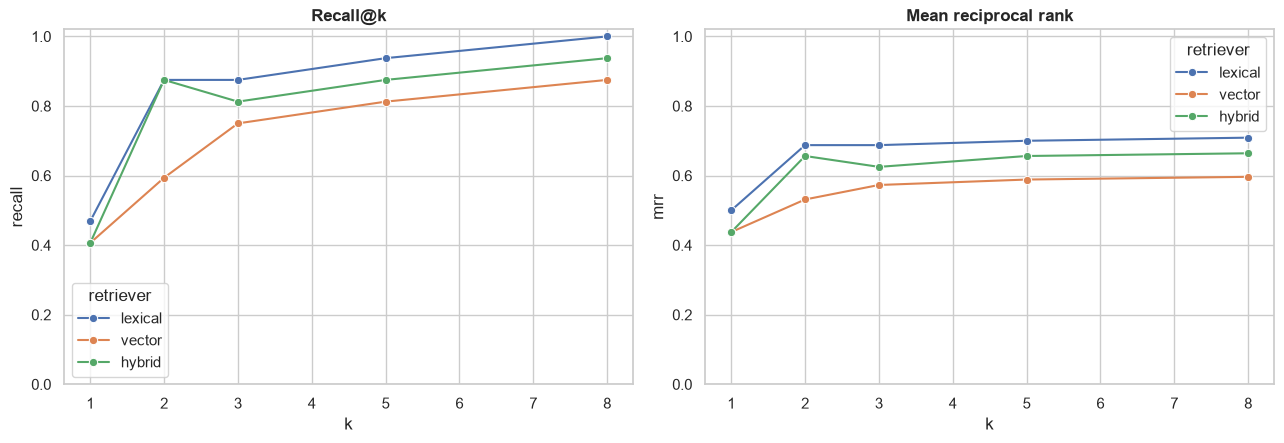

In [3]:
k_values = [1, 2, 3, 5, 8]
curve = []
for name, retriever in retrievers.items():
    for k in k_values:
        report = evaluate_retrieval(retriever, golden, top_k=k)
        curve.append({"retriever": name, "k": k, "recall": report.recall_at_k, "mrr": report.mean_reciprocal_rank})
curve_df = pd.DataFrame(curve)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharex=True)
sns.lineplot(data=curve_df, x="k", y="recall", hue="retriever", marker="o", ax=axes[0])
axes[0].set_title("Recall@k", weight="bold")
axes[0].set_ylim(0, 1.02)
sns.lineplot(data=curve_df, x="k", y="mrr", hue="retriever", marker="o", ax=axes[1])
axes[1].set_title("Mean reciprocal rank", weight="bold")
axes[1].set_ylim(0, 1.02)
plt.tight_layout()
plt.show()

In [4]:
curve_df.pivot_table(index="retriever", columns="k", values="recall").round(3)

k,1,2,3,5,8
retriever,,,,,
hybrid,0.406,0.875,0.812,0.875,0.938
lexical,0.469,0.875,0.875,0.938,1.000
vector,0.406,0.594,0.750,0.812,0.875


## 2. Hybrid weighting sweep

Hybrid fusion blends normalised scores as `alpha * lexical + (1 - alpha) *
vector`. Is 50/50 the right split? We sweep `alpha` end to end. With a weak
bag-of-words vector arm we *expect* lexical-heavy blends to win — and confirming
that expectation is exactly the point of measuring instead of guessing.

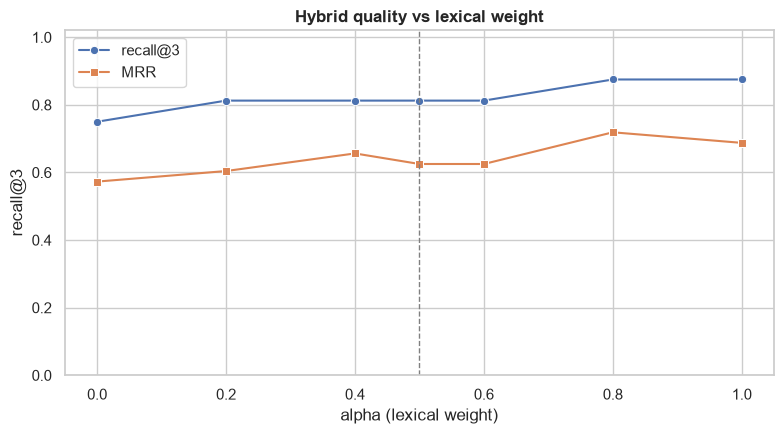

,alpha (lexical weight),recall@3,mrr
0,0.0,0.750,0.573
1,0.2,0.812,0.604
2,0.4,0.812,0.656
3,0.5,0.812,0.625
4,0.6,0.812,0.625
5,0.8,0.875,0.719
6,1.0,0.875,0.688


In [5]:
alphas = [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]
sweep = []
for alpha in alphas:
    blended = HybridRetriever(lexical, vector, lexical_weight=alpha, vector_weight=1 - alpha)
    report = evaluate_retrieval(blended, golden, top_k=3)
    sweep.append({"alpha (lexical weight)": alpha, "recall@3": report.recall_at_k, "mrr": report.mean_reciprocal_rank})
sweep_df = pd.DataFrame(sweep)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.lineplot(data=sweep_df, x="alpha (lexical weight)", y="recall@3", marker="o", label="recall@3", ax=ax)
sns.lineplot(data=sweep_df, x="alpha (lexical weight)", y="mrr", marker="s", label="MRR", ax=ax)
ax.axvline(0.5, color="grey", ls="--", lw=1)
ax.set_title("Hybrid quality vs lexical weight", weight="bold")
ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.show()
sweep_df.round(3)

## 3. Per-question win/loss analysis

Aggregate metrics hide *which* questions a strategy gets right. Here is the
reciprocal rank of the relevant chunk for every question and retriever — bright
cells are wins (relevant chunk near rank 1), dark cells are misses. This is how
you find the queries a strategy systematically fails.

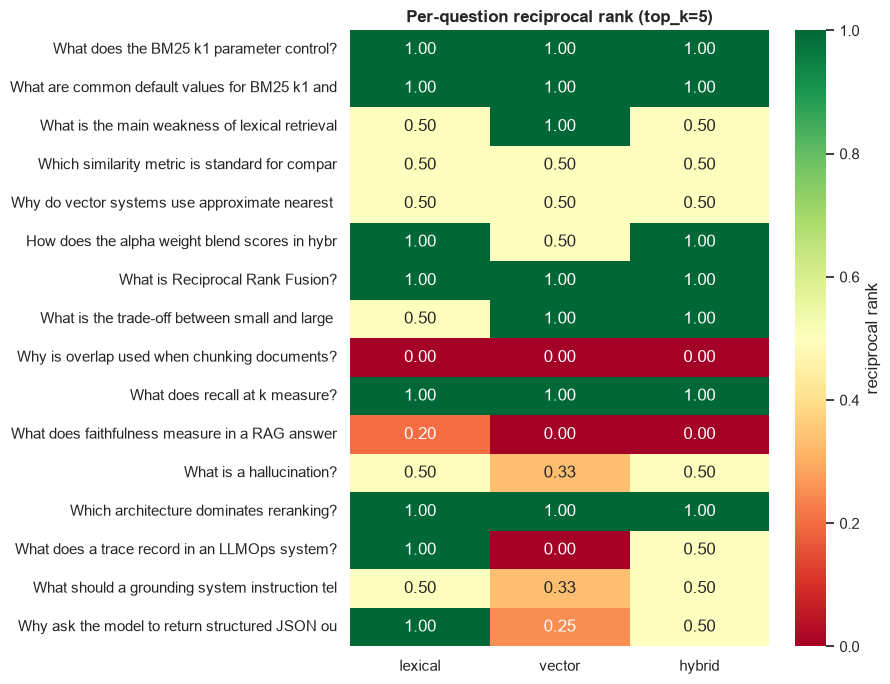

In [6]:
def first_relevant_rr(retriever, example, k=5):
    ids = [r.chunk.chunk_id for r in retriever.search(example.query, top_k=k)]
    relevant = set(example.relevant_chunk_ids)
    for position, chunk_id in enumerate(ids, start=1):
        if chunk_id in relevant:
            return 1.0 / position
    return 0.0


matrix = pd.DataFrame(
    {
        name: [first_relevant_rr(retriever, ex) for ex in golden]
        for name, retriever in retrievers.items()
    },
    index=[ex.query[:46] for ex in golden],
)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(matrix, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1, cbar_kws={"label": "reciprocal rank"}, ax=ax)
ax.set_title("Per-question reciprocal rank (top_k=5)", weight="bold")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

In [7]:
hard = matrix[(matrix["lexical"] < 0.5) | (matrix["vector"] < 0.5)].round(2)
print("Questions where at least one strategy struggles:")
hard

Questions where at least one strategy struggles:


,lexical,vector,hybrid
Why is overlap used when chunking documents?,0.0,0.00,0.0
What does faithfulness measure in a RAG answer,0.2,0.00,0.0
What is a hallucination?,0.5,0.33,0.5
What does a trace record in an LLMOps system?,1.0,0.00,0.5
What should a grounding system instruction tel,0.5,0.33,0.5
Why ask the model to return structured JSON ou,1.0,0.25,0.5


## 4. Swapping in real embeddings

Nothing above is tied to the fake embedder. Real semantic retrieval is a
one-line change — every cell that follows (evaluation, hybrid fusion, win/loss)
runs unchanged:

```python
from ragops_lab.retrieval import SentenceTransformerEmbeddingClient

vector = VectorRetriever(chunks, SentenceTransformerEmbeddingClient("all-MiniLM-L6-v2"))
```

## Takeaways

- On this corpus BM25 leads, the bag-of-words vector arm trails, and hybrid sits
  between — so naive 50/50 fusion **hurts**. The alpha sweep makes the right
  call (lexical-heavy) explicit.
- Per-question analysis is where real retrieval debugging happens; means alone
  would have hidden the queries the vector arm drops.
- Because every strategy implements the same `search` interface, comparing them
  — and upgrading to real embeddings — costs one line, not a rewrite.

Next — [`03_grounded_generation`](03_grounded_generation.ipynb) turns retrieved
context into cited, verifiable answers.